In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

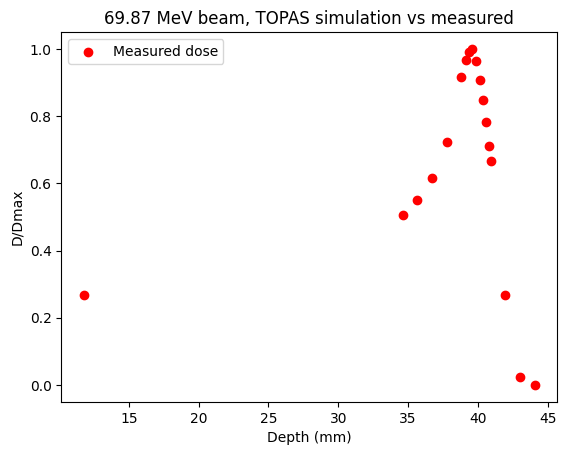

In [2]:
data = pd.read_excel(r"../Mid LET calculation/BP 69.87 measured - copy for scripts.xlsx")

BP_measured = pd.DataFrame()
BP_measured['Depth'] = data['Depth (mm)']
BP_measured['Dose'] = data['Dose (Gy)']/np.max(data['Dose (Gy)'])

plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
#plt.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

# Getting NIST data

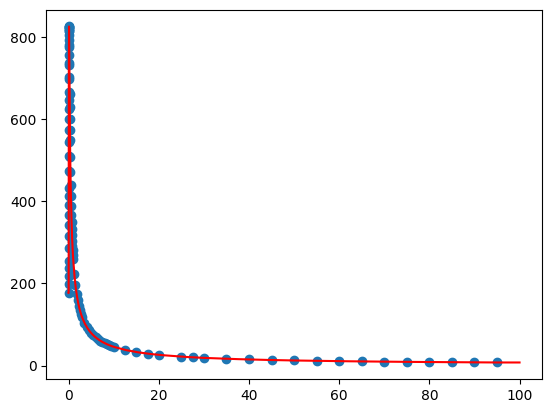

In [62]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

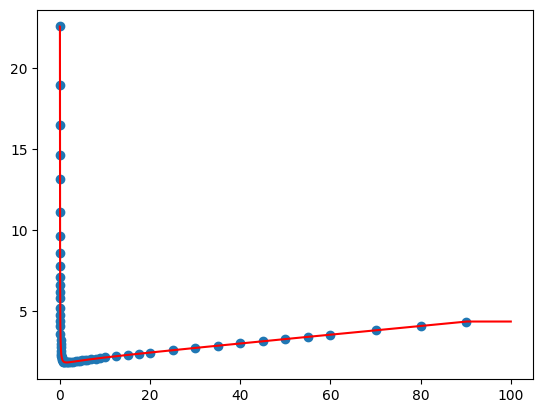

In [64]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# Reading in each particle phsp to calculate LET

In [60]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        mean_LET = round(particle_data['LET'].mean(),2)
        median_LET = round(particle_data['LET'].median(),2)

        #compute dose
        particle_data['Weight'] = particle_data['Weight']/len(particle_data)
        particle_data['Dose'] = particle_data['Weight']*particle_data['LET']

        dose = 1.602e-10*particle_data['Dose'].sum()
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        mean_LET = 0
        median_LET = 0
        dose = 0

    
    return mean_LET, median_LET, dose

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_11608\3047701424.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [61]:
dir = r"..\TOPAS_data\do_field"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'Mean LET', 'Median LET', 'Dose', 'Dose2'])
for file in list:
    if os.path.splitext(file)[-1] == '.phsp':
        newrow = {}
        newrow['Depth'] = float(os.path.splitext(file)[0])
        newrow['Mean LET'], newrow['Median LET'], newrow['Dose'] = Calculate_LET_from_phsp(os.path.join(dir,file), Expanded_SP, Expanded_SP_el)

        newrow = pd.DataFrame([newrow])
        topas_let = pd.concat([topas_let, newrow], ignore_index=True)


C:\Users\linux\AppData\Local\Temp\ipykernel_11608\3088625108.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


Text(0.5, 1.0, 'LET as function of depth')

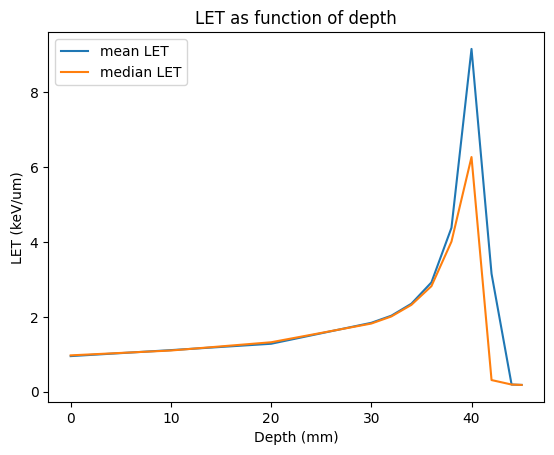

In [65]:
plt.plot(topas_let['Depth'], topas_let['Mean LET'], label='mean LET')
plt.plot(topas_let['Depth'], topas_let['Median LET'], label='median LET')
plt.legend()
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.title('LET as function of depth')

Text(0.5, 1.0, 'Dose as function of depth')

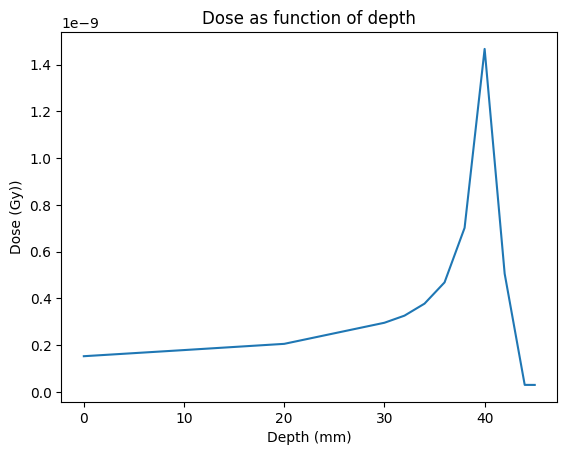

In [66]:
plt.plot(topas_let['Depth'], topas_let['Dose'])
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy))')
plt.title('Dose as function of depth')